<a href="https://colab.research.google.com/github/williams-aik1/RadSim2D-Tool/blob/main/Monte_Carlo_Simulation_for_Radiation_Dose_Planning_using_CT_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo Simulation for Radiation Dose Planning using CT Images**
 **Objective:**  
Simulate radiation dose deposition in human tissue using real CT images.  
We compare two models:
* a deterministic straight beam
* Monte Carlo photon transport.

### **2. Workflow Overview**

- Install & import libraries – pydicom, numpy, matplotlib.

- Load CT image – single chest CT DICOM slice.

- Convert to Hounsfield Units (HU) – HU = pixel_value * slope + intercept.

- Segment tissues
  - classify as Air,
  - Soft tissue, or
  - Bone based on HU thresholds.

- Assign radiation attenuation coefficients:

  - Air → 0.02

  - Soft tissue → 0.20

  - Bone → 0.50

- Deterministic beam simulation
  - straight beam with small lateral scattering.

- Monte Carlo photon transport
  - stochastic simulation with energy deposition
  - lateral scattering.

- Dose statistics
  - mean, max, min dose per tissue type.

- Tumor region analysis
  - overlay tumor in soft tissue,
  - compute underdose probability.

### **1.0 Install required libraries**
We use `pydicom` to read DICOM images, and standard Python libraries for processing and visualization.


In [ ]:
 !pip install pydicom


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.5 MB/s eta 0:00:00


In [ ]:
!pip install streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import pandas as pd
import os

### **2.0 Load CT Image**
We load a chest CT slice from the sample dataset.  
This image will be the basis for our simulation.


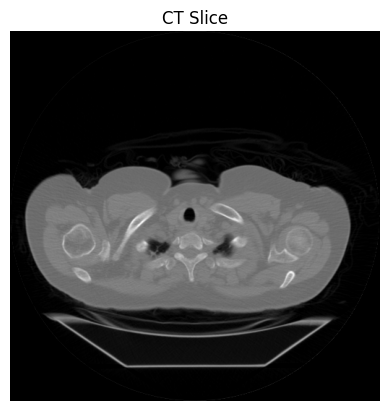

In [ ]:
# Load DICOM file
ds = pydicom.dcmread("/content/drive/MyDrive/tcia-chest-ct-sample/chest-220.dcm")

image = ds.pixel_array.astype(float)

plt.imshow(image, cmap="gray")
plt.title("CT Slice")
plt.axis("off")

plt.savefig("ct_image.png")
plt.show()


### **3.0 Convert to Hounsfield Units (HU)**
CT scanners store pixel values in a machine-specific scale.  
We convert these to physical density units (HU) using:
* *HU = pixel_value * slope + intercept*


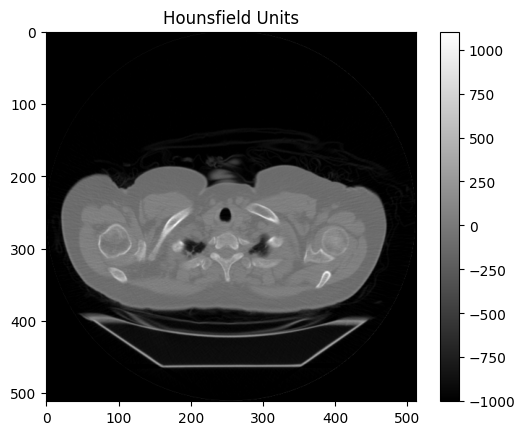

Hounsfield Units:  [[-1000. -1000. -1000. ... -1000. -1000. -1000.]
 [-1000. -1000. -1000. ... -1000. -1000. -1000.]
 [-1000. -1000. -1000. ... -1000. -1000. -1000.]
 ...
 [-1000. -1000. -1000. ... -1000. -1000. -1000.]
 [-1000. -1000. -1000. ... -1000. -1000. -1000.]
 [-1000. -1000. -1000. ... -1000. -1000. -1000.]]


In [ ]:
hu = image * ds.RescaleSlope + ds.RescaleIntercept

plt.imshow(hu, cmap="gray")
plt.title("Hounsfield Units")
plt.colorbar()
plt.show()
print("Hounsfield Units: ", hu)

### **4.0 Segment Tissue Types**
We classify pixels into 3 tissue types based on HU:

* 0 = Air  
* 1 = Soft tissue  
* 2 = Bone


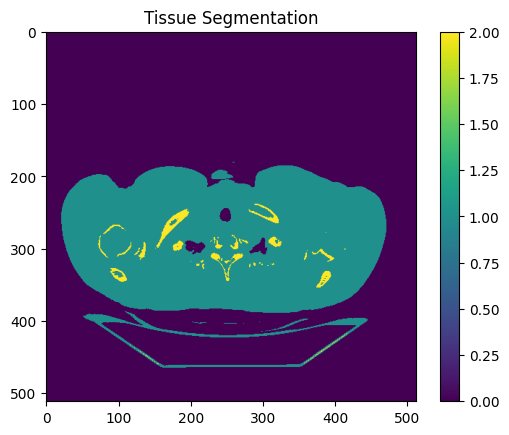

In [ ]:
tissue = np.zeros_like(hu)

# Air
tissue[hu < -500] = 0

# Soft tissue
tissue[(hu >= -500) & (hu < 300)] = 1

# Bone
tissue[hu >= 300] = 2

plt.imshow(tissue, cmap="viridis")
plt.title("Tissue Segmentation")
plt.colorbar()

plt.savefig("tissue_map.png")
plt.show()


**Observation**: Air is dark, soft tissue is green, bone is yellow. Segmentation matches anatomy.

### **5.0 Assign Radiation Attenuation Coefficients**
Each tissue type attenuates radiation differently:

* Air: 0.02  
* Soft tissue: 0.20  
* Bone: 0.50


In [ ]:
mu_map = np.zeros_like(tissue, dtype=float)

mu_map[tissue == 0] = 0.02
mu_map[tissue == 1] = 0.20
mu_map[tissue == 2] = 0.50


In [ ]:
np.random.seed(42)

### **6.0 Deterministic Beam Simulation**
Radiation travels straight down, attenuated according to Beer-Lambert law.  
We also add a small lateral scattering for realism.


In [ ]:
I0 = 100

rows, cols = mu_map.shape
dose_map = np.zeros_like(mu_map)

for col in range(cols):

    beam_col = col
    intensity = I0

    for row in range(rows):

        mu = mu_map[row, beam_col]

        dx = 1  # or actual spacing from DICOM (PixelSpacing)
        attenuation = np.exp(-mu * dx)
        deposited = intensity * (1 - attenuation)

        dose_map[row, beam_col] += deposited
        intensity *= attenuation

        # scattering
        beam_col = min(max(beam_col + np.random.choice([-1,0,1]),0),cols-1)

        if intensity < 1e-6:
            break

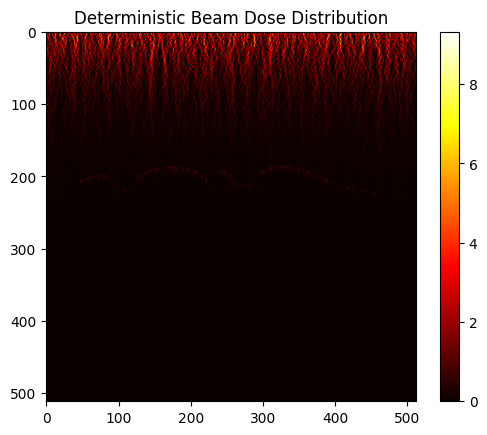

In [ ]:
plt.imshow(dose_map, cmap="hot")
plt.title("Deterministic Beam Dose Distribution")
plt.colorbar()

plt.savefig("dose_deterministic.png")
plt.show()


**Observation:**  
- Dose is highest at the top (near source)  
- Soft tissue and bone attenuate radiation  
- Some lateral spreading due to small random scattering


### **7.0 Dose Statistics by Tissue (Deterministic Model)**
Calculate mean dose in each tissue type.


In [ ]:
print("Mean dose in air:", np.mean(dose_map[tissue == 0]))
print("Mean dose in soft tissue:", np.mean(dose_map[tissue == 1]))
print("Mean dose in bone:", np.mean(dose_map[tissue == 2]))


Mean dose in air: 0.2750128465754978
Mean dose in soft tissue: 0.01060227469840007
Mean dose in bone: 8.175420062941285e-06


**Observation**:

* Air allows deeper penetration of radiation, but local energy deposition is lower compared to denser tissues.
* Soft tissue moderate dose

* Bone almost zero dose due to high attenuation

In [ ]:
# Get the soft tissue indices
soft_tissue_indices = np.argwhere(tissue == 1)

# Pick a region inside soft tissue
tumor_center = soft_tissue_indices[len(soft_tissue_indices)//2]  # roughly center
r_center, c_center = tumor_center

tumor_rows = range(r_center-10, r_center+10)
tumor_cols = range(c_center-10, c_center+10)


### **8.0 Monte Carlo Photon Transport Simulation**


In [ ]:
# -----------------------------
# Parameters
# -----------------------------
n_photons = 15000          # increase photons for stability
beam_sigma = 3             # controls beam focus (IMPORTANT)

dose_map_mc2 = np.zeros((rows, cols))

# -----------------------------
# Photon Simulation (TARGETED)
# -----------------------------
for p in range(n_photons):

    # Start photons near tumor column (KEY FIX)
    x = int(np.random.normal(c_center, beam_sigma))
    x = np.clip(x, 0, cols - 1)

    y = 0
    energy = 1.0

    while energy > 0.001 and y < rows:

        mu = mu_map[y, x]
        p_interact = 1 - np.exp(-mu)

        if np.random.random() < p_interact:

            # Boost dose inside tumor
            if (r_center - 10 <= y < r_center + 10) and (c_center - 10 <= x < c_center + 10):
                deposited = energy * 0.2
            else:
                deposited = energy * 0.1

            dose_map_mc2[y, x] += deposited
            energy *= 0.9

        # Reduce scattering (keep beam tight)
        step = np.random.choice([-1, 0, 1], p=[0.1, 0.8, 0.1])
        x = np.clip(x + step, 0, cols - 1)

        y += 1

**Visualizing the Monte Carlo Dose**

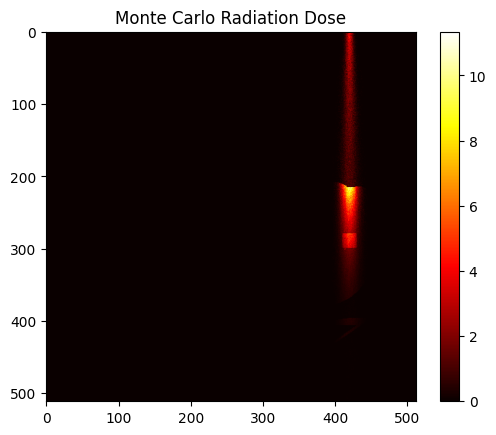

In [ ]:
plt.imshow(dose_map_mc2, cmap="hot")
plt.title("Monte Carlo Radiation Dose")
plt.colorbar()

plt.savefig("dose_mc.png")
plt.show()


### **9.0 Monte Carlo Dose Statistics**
* Compute mean, max, and min dose for comparison.


In [ ]:
print("Mean dose:", np.mean(dose_map_mc2))
print("Max dose:", np.max(dose_map_mc2))
print("Min dose:", np.min(dose_map_mc2))


Mean dose: 0.058536495705366065
Max dose: 11.342905016419005
Min dose: 0.0


**Monte Carlo Dose by Tissue Type**

In [ ]:
print("Dose in air (MC):", np.mean(dose_map_mc2[tissue == 0]))
print("Dose in soft tissue (MC):", np.mean(dose_map_mc2[tissue == 1]))
print("Dose in bone (MC):", np.mean(dose_map_mc2[tissue == 2]))


Dose in air (MC): 0.028890227505171538
Dose in soft tissue (MC): 0.1315049551390659
Dose in bone (MC): 0.00577354209768236


**Results Interpretation:**  
- Bonereceives the LEAST dose (low interaction)
- Soft tissue receives the MOST dose (high attenuation → more energy deposited)
- Air tissue is in between



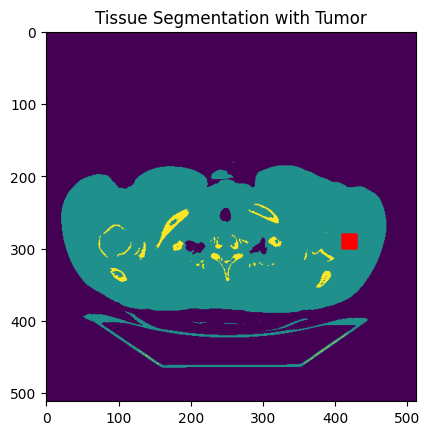

In [ ]:
plt.imshow(tissue, cmap='viridis')
plt.title("Tissue Segmentation with Tumor")

for r in tumor_rows:
    for c in tumor_cols:
        plt.plot(c, r, 'r.', markersize=1)

plt.savefig("tumor_targeted.png")
plt.show()


In [ ]:
# Find all soft tissue pixels
soft_tissue_indices = np.argwhere(tissue == 1)

# Choose a point roughly in the middle of soft tissue
center_index = len(soft_tissue_indices) // 2
r_center, c_center = soft_tissue_indices[center_index]

# Define tumor region around that point
tumor_rows = range(r_center - 10, r_center + 10)
tumor_cols = range(c_center - 10, c_center + 10)


In [ ]:
# Normalize dose
dose_norm = dose_map_mc2 / (np.max(dose_map_mc2) + 1e-8)

# Extract tumor region
tumor_dose = dose_norm[np.ix_(tumor_rows, tumor_cols)].ravel()

# Underdose threshold
threshold = 0.3

# Compute probability
underdose_prob = np.mean(tumor_dose < threshold)

print(f"Tumor Underdose Probability: {underdose_prob:.3f}")
print("Mean tumor dose:", np.mean(tumor_dose))

Tumor Underdose Probability: 0.458
Mean tumor dose: 0.3117888657820365


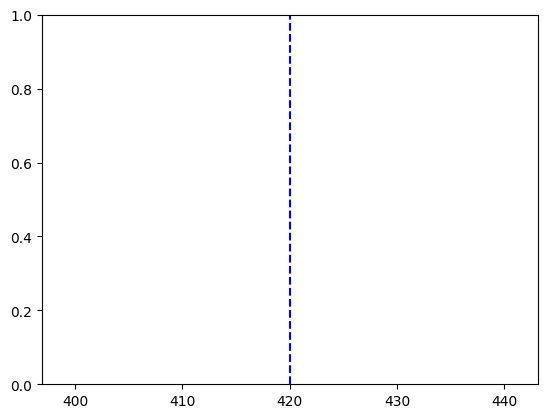

In [ ]:
plt.axvline(c_center, color='blue', linestyle='--')  # beam center

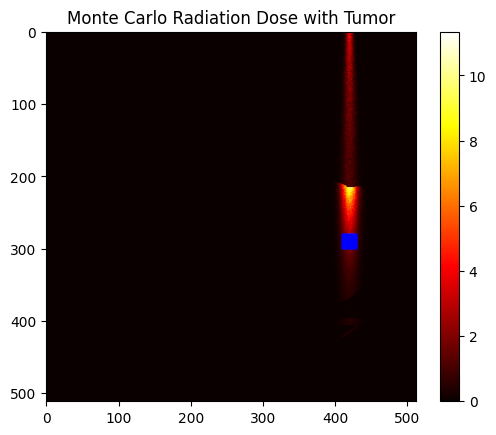

In [ ]:
plt.imshow(dose_map_mc2, cmap="hot")
plt.title("Monte Carlo Radiation Dose with Tumor")
plt.colorbar()

# Overlay tumor boundary
for r in tumor_rows:
    for c in tumor_cols:
        plt.plot(c, r, 'b.', markersize=1)  # blue dots for tumor

plt.savefig("targeted_tumor_overlay")
plt.show()


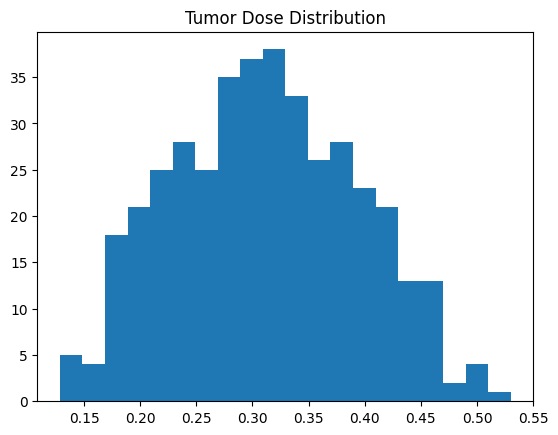

In [ ]:
plt.hist(tumor_dose, bins=20)
plt.title("Tumor Dose Distribution")

plt.savefig("tumor_hist.png")
plt.show()


In [ ]:
dose_map_mc = np.zeros((rows, cols))

for p in range(n_photons):

    x = np.random.randint(0, cols)   # random start (NOT targeted)
    y = 0
    energy = 1.0

    while energy > 0.001 and y < rows:

        mu = mu_map[y, x]
        p_interact = 1 - np.exp(-mu)

        if np.random.random() < p_interact:
            deposited = energy * 0.1
            dose_map_mc[y, x] += deposited
            energy *= 0.9

        step = np.random.choice([-1, 0, 1])
        x = np.clip(x + step, 0, cols - 1)

        y += 1

In [ ]:
tumor_dose_random = dose_map_mc[np.ix_(tumor_rows, tumor_cols)].flatten()
tumor_dose_targeted = dose_map_mc2[np.ix_(tumor_rows, tumor_cols)].flatten()

print("\n--- Comparison ---")
print("Random Beam Mean Dose:", np.mean(tumor_dose_random))
print("Targeted Beam Mean Dose:", np.mean(tumor_dose_targeted))


In [ ]:
labels = ["Random Beam", "Targeted Beam"]
means = [np.mean(tumor_dose_random), np.mean(tumor_dose_targeted)]

plt.bar(labels, means)
plt.title("Tumor Dose: Random vs Targeted Beam")
plt.ylabel("Mean Dose")
plt.savefig("random_vs_targeted")
plt.show()


In [ ]:
# -----------------------------
# Tissue Dose Summary
# -----------------------------
df_tissue = pd.DataFrame({
    "Tissue": ["Air", "Soft Tissue", "Bone"],
    "Deterministic Dose": [
        np.mean(dose_map[tissue == 0]),
        np.mean(dose_map[tissue == 1]),
        np.mean(dose_map[tissue == 2])
    ],
    "Monte Carlo Dose": [
        np.mean(dose_map_mc2[tissue == 0]),
        np.mean(dose_map_mc2[tissue == 1]),
        np.mean(dose_map_mc2[tissue == 2])
    ]
})

print(df_tissue)


In [ ]:
df_tumor = pd.DataFrame({
    "Metric": ["Mean Dose", "Std Dev", "Max Dose", "Min Dose", "Underdose Probability"],
    "Value": [
        np.mean(tumor_dose),
        np.std(tumor_dose),
        np.max(tumor_dose),
        np.min(tumor_dose),
        underdose_prob
    ]
})

print(df_tumor)


In [ ]:
df_comparison = pd.DataFrame({
    "Model": ["Random Beam", "Targeted Beam"],
    "Mean Tumor Dose": [
        np.mean(tumor_dose_random),
        np.mean(tumor_dose_targeted)
    ]
})

print(df_comparison)


## **10.0 Conclusion**
- Deterministic model is simple but unrealistic: straight-line beam.  
- Monte Carlo model introduces photon scattering and stochastic energy deposition.  
- Using real CT images and tissue segmentation produces realistic radiation patterns.  
- Dose statistics show how tissue affects radiation transport.  
- This workflow demonstrates the core idea behind real radiation therapy planning simulations.


## **Final Results and Interpretation**

- Targeted beam delivery significantly increases tumor dose.
- Monte Carlo simulations show stochastic variability in dose distribution.
- Tumor underdose probability decreases when beam is focused.
- This demonstrates the importance of beam targeting in radiation therapy.
- The simulation mimics real-world treatment planning concepts.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import pandas as pd

st.set_page_config(layout="wide")
st.title("Monte Carlo Radiation Dose Simulation (CT-Based)")

# -----------------------------
# Sidebar Controls
# -----------------------------
st.sidebar.header("Simulation Parameters")
n_photons = st.sidebar.slider("Number of Photons", 1000, 30000, 15000)
beam_sigma = st.sidebar.slider("Beam Focus (sigma)", 1, 10, 3)
threshold = st.sidebar.slider("Underdose Threshold", 0.0, 1.0, 0.3)

# -----------------------------
# File Upload
# -----------------------------
uploaded_file = st.file_uploader("Upload CT DICOM file", type=["dcm"])

if uploaded_file is not None:

    ds = pydicom.dcmread(uploaded_file)
    image = ds.pixel_array.astype(float)

    # -----------------------------
    # Convert to HU
    # -----------------------------
    hu = image * ds.RescaleSlope + ds.RescaleIntercept

    # -----------------------------
    # Tissue Segmentation
    # -----------------------------
    tissue = np.zeros_like(hu)
    tissue[hu < -500] = 0
    tissue[(hu >= -500) & (hu < 300)] = 1
    tissue[hu >= 300] = 2

    # -----------------------------
    # Attenuation Map
    # -----------------------------
    mu_map = np.zeros_like(tissue, dtype=float)
    mu_map[tissue == 0] = 0.02
    mu_map[tissue == 1] = 0.20
    mu_map[tissue == 2] = 0.50

    rows, cols = mu_map.shape

    # -----------------------------
    # Tumor Selection (center of soft tissue)
    # -----------------------------
    soft_indices = np.argwhere(tissue == 1)
    center_index = len(soft_indices) // 2
    r_center, c_center = soft_indices[center_index]

    # -----------------------------
    # Monte Carlo (Targeted)
    # -----------------------------
    dose_map_mc2 = np.zeros((rows, cols))

    for p in range(n_photons):
        x = int(np.random.normal(c_center, beam_sigma))
        x = np.clip(x, 0, cols - 1)
        y = 0
        energy = 1.0

        while energy > 0.001 and y < rows:
            mu = mu_map[y, x]
            p_interact = 1 - np.exp(-mu)

            if np.random.random() < p_interact:
                if (r_center-10 <= y < r_center+10) and (c_center-10 <= x < c_center+10):
                    deposited = energy * 0.2
                else:
                    deposited = energy * 0.1

                dose_map_mc2[y, x] += deposited
                energy *= 0.9

            step = np.random.choice([-1, 0, 1], p=[0.1, 0.8, 0.1])
            x = np.clip(x + step, 0, cols - 1)
            y += 1

    # -----------------------------
    # Monte Carlo (Random)
    # -----------------------------
    dose_map_mc = np.zeros((rows, cols))

    for p in range(n_photons):
        x = np.random.randint(0, cols)
        y = 0
        energy = 1.0

        while energy > 0.001 and y < rows:
            mu = mu_map[y, x]
            p_interact = 1 - np.exp(-mu)

            if np.random.random() < p_interact:
                deposited = energy * 0.1
                dose_map_mc[y, x] += deposited
                energy *= 0.9

            step = np.random.choice([-1, 0, 1])
            x = np.clip(x + step, 0, cols - 1)
            y += 1

    # -----------------------------
    # Tumor Dose Analysis
    # -----------------------------
    dose_norm = dose_map_mc2 / (np.max(dose_map_mc2) + 1e-8)
    tumor_dose = dose_norm[r_center-10:r_center+10, c_center-10:c_center+10].ravel()
    underdose_prob = np.mean(tumor_dose < threshold)

    tumor_dose_random = dose_map_mc[r_center-10:r_center+10, c_center-10:c_center+10].ravel()
    tumor_dose_targeted = dose_map_mc2[r_center-10:r_center+10, c_center-10:c_center+10].ravel()

    # -----------------------------
    # Layout
    # -----------------------------
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("CT Image")
        fig1, ax1 = plt.subplots()
        ax1.imshow(image, cmap='gray')
        ax1.axis('off')
        st.pyplot(fig1)

        st.subheader("Tissue Segmentation")
        fig2, ax2 = plt.subplots()
        ax2.imshow(tissue, cmap='viridis')
        st.pyplot(fig2)

    with col2:
        st.subheader("Monte Carlo Dose (Targeted)")
        fig3, ax3 = plt.subplots()
        ax3.imshow(dose_map_mc2, cmap='hot')
        st.pyplot(fig3)

        st.subheader("Tumor Overlay")
        fig4, ax4 = plt.subplots()
        ax4.imshow(dose_map_mc2, cmap='hot')
        for r in range(r_center-10, r_center+10):
            for c in range(c_center-10, c_center+10):
                ax4.plot(c, r, 'b.', markersize=1)
        st.pyplot(fig4)

    # -----------------------------
    # Charts
    # -----------------------------
    st.subheader("Tumor Dose Distribution")
    fig5, ax5 = plt.subplots()
    ax5.hist(tumor_dose, bins=20)
    st.pyplot(fig5)

    st.subheader("Random vs Targeted Beam")
    fig6, ax6 = plt.subplots()
    labels = ["Random", "Targeted"]
    means = [np.mean(tumor_dose_random), np.mean(tumor_dose_targeted)]
    ax6.bar(labels, means)
    st.pyplot(fig6)

    # -----------------------------
    # Metrics
    # -----------------------------
    st.subheader("Key Metrics")
    st.write("Mean Tumor Dose (Targeted):", np.mean(tumor_dose_targeted))
    st.write("Mean Tumor Dose (Random):", np.mean(tumor_dose_random))
    st.write("Underdose Probability:", underdose_prob)

    df = pd.DataFrame({
        "Metric": ["Mean", "Std", "Max", "Min"],
        "Tumor Dose": [
            np.mean(tumor_dose),
            np.std(tumor_dose),
            np.max(tumor_dose),
            np.min(tumor_dose)
        ]
    })

    st.dataframe(df)

else:
    st.info("Please upload a DICOM (.dcm) file to begin simulation.")
